What is Customer Purchase Behavior Analysis?

Customer Purchase Behavior Analysis is a process used to understand how customers interact with products and services. It involves analyzing customer data such as income, purchase patterns, and satisfaction levels to identify trends and make business decisions.

Why do we analyze customer purchase behavior?

In real-world business scenarios, companies need to understand their customers to increase sales and improve satisfaction. Raw data often contains hidden patterns that are not directly visible.

By analyzing customer behavior:
- Businesses can identify high-value customers  
- Improve marketing strategies  
- Increase customer retention  
- Optimize product offerings  

No insights? No business growth!

Customer data is a valuable asset. Without proper analysis, businesses cannot understand customer needs or improve their services. Data analysis helps convert raw data into meaningful insights that drive growth.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Description

What information does the dataset contain?

The dataset contains 12 columns related to customer purchase behavior, which are:

-age: Age of the customer.
-gender: Gender of the customer (0 for Male, 1 for Female).
-income: Annual income of the customer.
-education: Education level of the customer.
-region: Region where the customer resides.
-loyalty_status: Loyalty status of the customer.
-purchase_frequency: Frequency of purchases made by the customer.
-purchase_amount: Amount spent by the customer in each purchase.
-product_category: Category of the purchased product.
-promotion_usage: Indicates whether the customer used promotional offers (0 for No, 1 for Yes).
-satisfaction_score: Satisfaction score of the customer.

In [10]:
df= pd.read_csv('customer_data.csv')
df.head()

,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,1,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,0,6
1,2,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,1,6
2,3,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,0,6
3,4,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,0,7
4,5,31,Female,46952,College,North,Regular,occasional,19685,Clothing,1,5


1  Initial Interrogation (Understanding the Data)

Before analyzing customer purchase behavior, we need to understand the structure and contents of the dataset.
- shape() : shows the total number of rows and columns in the dataset.
- columns() : lists all the feature names present in the dataset.
- head() : Displays the first few rows of the dataset (sample data).
- info() : Provides information about data types, non-null values, and structure.
- describe() : Generates statistical summary of numerical features.

In [11]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id                  100000 non-null  int64 
 1   age                 100000 non-null  int64 
 2   gender              100000 non-null  object
 3   income              100000 non-null  int64 
 4   education           100000 non-null  object
 5   region              100000 non-null  object
 6   loyalty_status      100000 non-null  object
 7   purchase_frequency  100000 non-null  object
 8   purchase_amount     100000 non-null  int64 
 9   product_category    100000 non-null  object
 10  promotion_usage     100000 non-null  int64 
 11  satisfaction_score  100000 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 9.2+ MB


In [12]:
df.describe()

,id,age,income,purchase_amount,promotion_usage,satisfaction_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,30.003260,27516.269880,9634.790840,0.300800,5.009650
std,28867.657797,4.480535,12996.782587,4799.339449,0.458608,1.038714
min,1.000000,12.000000,5000.000000,1118.000000,0.000000,0.000000
25%,25000.750000,27.000000,16271.750000,5583.000000,0.000000,4.000000
50%,50000.500000,30.000000,27584.500000,9452.000000,0.000000,5.000000
75%,75000.250000,33.000000,38747.250000,13350.000000,1.000000,6.000000
max,100000.000000,49.000000,50000.000000,26204.000000,1.000000,10.000000


In [13]:
df.head()

,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,1,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,0,6
1,2,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,1,6
2,3,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,0,6
3,4,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,0,7
4,5,31,Female,46952,College,North,Regular,occasional,19685,Clothing,1,5


2 Data Quality Check

- df.isnull().sum() shows that there are no missing values in the dataset.  

- df.duplicated().sum() shows that there are no duplicate records.  

- Conclusion: The dataset is clean and ready for further analysis.

In [14]:
df.isnull().sum()

id                    0
age                   0
gender                0
income                0
education             0
region                0
loyalty_status        0
purchase_frequency    0
purchase_amount       0
product_category      0
promotion_usage       0
satisfaction_score    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

3 Data Analysis & Visualization

- Outliers are detected using boxplot. A few high-value customers are present and kept for analysis.  

- The histogram shows that most customers spend in the low to medium range.  

- The scatter plot indicates that higher income leads to higher purchase.  

- The heatmap shows a strong relationship between income and purchase amount.  

Conclusion: Income is the main factor influencing customer purchase behavior.

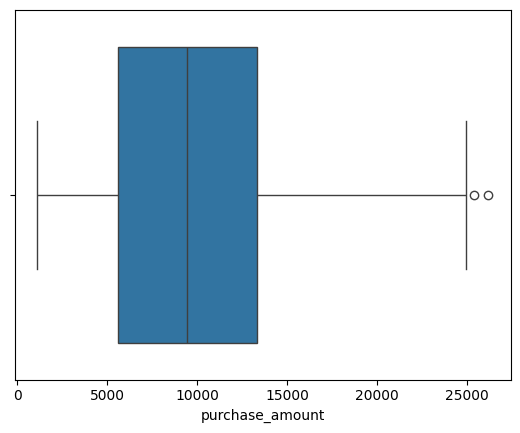

In [16]:
sns.boxplot(x=df['purchase_amount'])
plt.show()

In [17]:
q1 = df['purchase_amount'].quantile(0.25)
q3 = df['purchase_amount'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['purchase_amount'] < lower) | (df['purchase_amount'] > upper)]

outliers

,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
72791,72792,32,Female,48213,College,North,Regular,rare,25406,Electronics,0,6
91489,91490,34,Male,49710,Bachelor,North,Silver,frequent,26204,Clothing,0,6


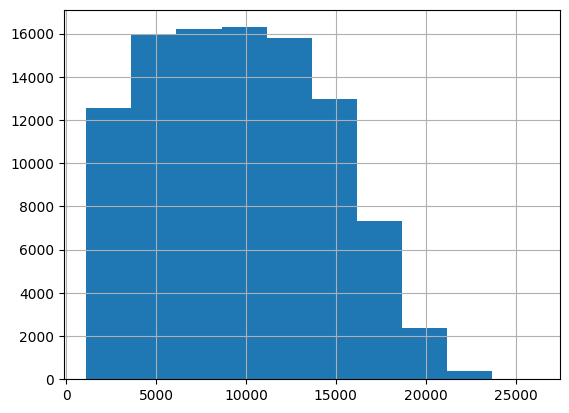

In [18]:
df['purchase_amount'].hist()
plt.show()

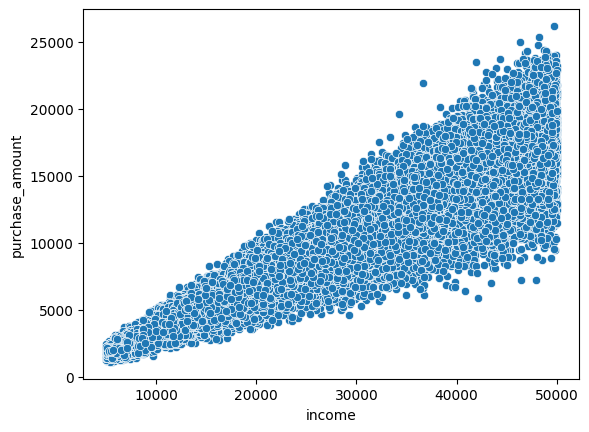

In [19]:
sns.scatterplot(x='income', y='purchase_amount', data=df)
plt.show()

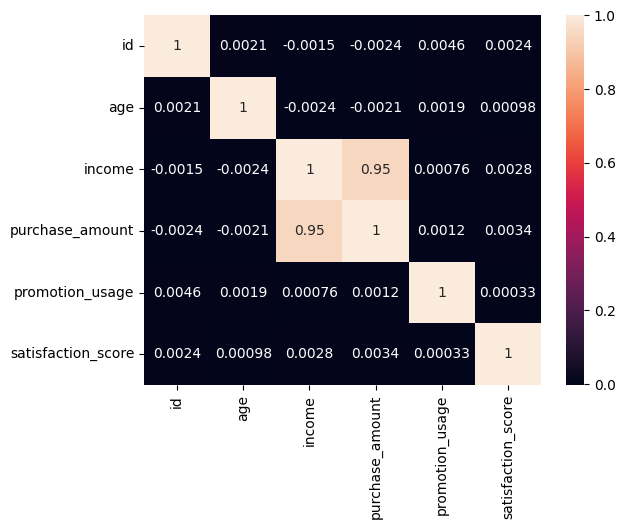

In [20]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.show()

In [21]:
df_clean = df.copy()

In [22]:
df_clean = df_clean.drop('id', axis=1)

In [23]:
df_clean.head()

,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,0,6
1,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,1,6
2,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,0,6
3,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,0,7
4,31,Female,46952,College,North,Regular,occasional,19685,Clothing,1,5


Data Preprocessing

- Encoding

Categorical features such as gender, education, region, loyalty status, product category, and purchase frequency are converted into numerical values using Label Encoding.  
This is done because machine learning models cannot understand text data.

- Feature Scaling

Numerical features like age, income, purchase amount, and satisfaction score are scaled using StandardScaler.  
This ensures that all features are on the same scale and improves model performance.

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['gender', 'education', 'region', 'loyalty_status', 'product_category', 'purchase_frequency']

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

In [25]:
df_clean.head()

,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,27,1,40682,0,0,0,0,18249,1,0,6
1,29,1,15317,3,3,1,2,4557,2,1,6
2,37,1,38849,0,3,2,2,11822,2,0,6
3,30,1,11568,2,2,1,0,4098,4,0,7
4,31,0,46952,1,1,1,1,19685,2,1,5


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['age','income','purchase_amount','satisfaction_score']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

In [27]:
df_clean.head()

,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,-0.670294,1,1.013004,0,0,0,0,1.794883,1,0,0.953443
1,-0.223916,1,-0.938642,3,3,1,2,-1.058024,2,1,0.953443
2,1.561594,1,0.871969,0,3,2,2,0.455734,2,0,0.953443
3,-0.000728,1,-1.227100,2,2,1,0,-1.153663,4,0,1.916176
4,0.222461,0,1.495434,1,1,1,1,2.094092,2,1,-0.009290


Feature Engineering & Data Split

- Customer Segment is created based on purchase amount (Low, Medium, High) to group customers.  

- The data is then split into training and testing sets (80% training, 20% testing).  

In [28]:
df_clean['Customer_Segment'] = pd.cut(df['purchase_amount'],
                                      bins=3,
                                      labels=['Low','Medium','High'])

In [29]:
df_clean[['purchase_amount','Customer_Segment']].head()

,purchase_amount,Customer_Segment
0,1.794883,High
1,-1.058024,Low
2,0.455734,Medium
3,-1.153663,Low
4,2.094092,High


In [ ]:
from sklearn.model_selection import train_test_split

# Features (input)
X = df_clean.drop('Customer_Segment', axis=1)

# Target (output)
y = df_clean['Customer_Segment']

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 11)
(20000, 11)
(80000,)
(20000,)


Principal Component Analysis (PCA)

- PCA is used to reduce the number of features while keeping important information.  

- It transforms the data into new components (PC1, PC2, etc.).  

- The scree plot helps in selecting the important components.  

 PCA reduces complexity and helps in better data visualization.

In [33]:
from sklearn.decomposition import PCA

pca = PCA()
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [34]:
from sklearn.decomposition import PCA

# PCA object
pca = PCA()

# Fit PCA on training data
X_pca = pca.fit_transform(X_train)

In [35]:
pca.explained_variance_ratio_

array([0.2237957 , 0.19419999, 0.14506595, 0.10018542, 0.09985655,
       0.08863407, 0.06123109, 0.03578696, 0.02499062, 0.02110396,
       0.00514971])

In [36]:
pca_final = PCA(n_components=8)

X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)

In [37]:
X_train_pca.shape
X_test_pca.shape

(20000, 8)

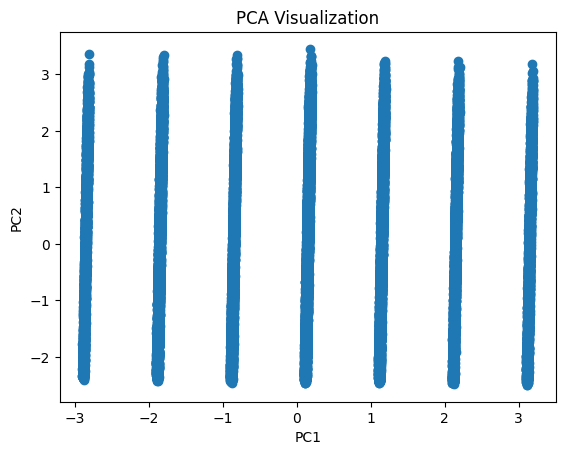

In [38]:

plt.scatter(X_train_pca[:,0], X_train_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

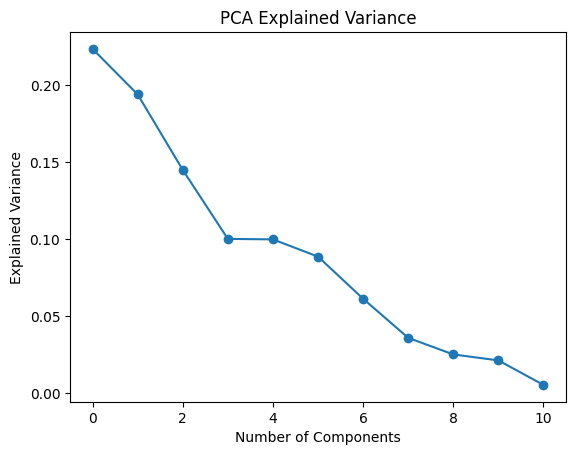

In [39]:

plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

 Linear Discriminant Analysis (LDA)

- LDA is used to reduce dimensions while separating different classes.  

- It transforms the data into new axes (LD1, LD2) to maximize class separation.  

- The visualization shows clear grouping of Low, Medium, and High customers.  

 LDA helps in better classification by clearly separating customer segments.

In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [41]:

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

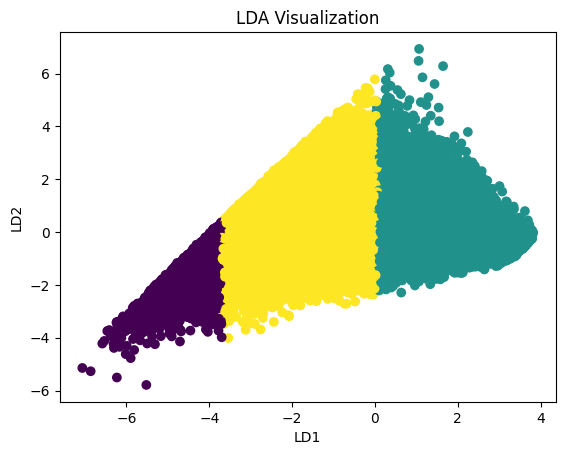

In [43]:
plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=y_train_encoded)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA Visualization')
plt.show()

In [44]:
df_clean.describe()

,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
count,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.00000,100000.000000,100000.00000,1.000000e+05,100000.00000,100000.000000,1.000000e+05
mean,-2.100364e-16,0.499260,1.364242e-17,1.093840,1.49869,1.200660,1.29924,7.020162e-17,2.85361,0.300800,2.694023e-16
std,1.000005e+00,0.500002,1.000005e+00,0.941776,1.20424,0.598631,0.78205,1.000005e+00,1.49629,0.458608,1.000005e+00
min,-4.018125e+00,0.000000,-1.732458e+00,0.000000,0.00000,0.000000,0.00000,-1.774585e+00,0.00000,0.000000,-4.822957e+00
25%,-6.702939e-01,0.000000,-8.651815e-01,0.000000,0.00000,1.000000,1.00000,-8.442435e-01,2.00000,0.000000,-9.720237e-01
50%,-7.275954e-04,0.000000,5.249796e-03,1.000000,2.00000,1.000000,2.00000,-3.808686e-02,3.00000,0.000000,-9.290377e-03
75%,6.688387e-01,1.000000,8.641397e-01,2.000000,3.00000,2.000000,2.00000,7.741123e-01,4.00000,1.000000,9.534430e-01
max,4.239859e+00,1.000000,1.729955e+00,3.000000,3.00000,2.000000,2.00000,3.452411e+00,6.00000,1.000000,4.804376e+00


 Key Metrics (KPI)

- Average income and purchase amount are calculated to understand customer spending.  

- Total number of customers gives the dataset size.  

- Average satisfaction score shows overall customer satisfaction level.  

 These metrics help in understanding overall customer behavior and business performance.

In [45]:
# Average income
df['income'].mean()

# Average purchase amount
df['purchase_amount'].mean()

# Total customers
df.shape[0]

# Avg satisfaction
df['satisfaction_score'].mean()

np.float64(5.00965)

In [46]:
print("Average Income:", df['income'].mean())
print("Average Purchase Amount:", df['purchase_amount'].mean())
print("Total Customers:", df.shape[0])
print("Average Satisfaction Score:", df['satisfaction_score'].mean())

Average Income: 27516.26988
Average Purchase Amount: 9634.79084
Total Customers: 100000
Average Satisfaction Score: 5.00965


 Final Data Visualization

- The histogram shows that most customers have low to medium purchase amounts.  

- The scatter plot shows a positive relationship between income and purchase.  

- The bar chart shows that most customers belong to Low and Medium segments.  

 Customer income influences spending, and most customers are in lower spending categories.

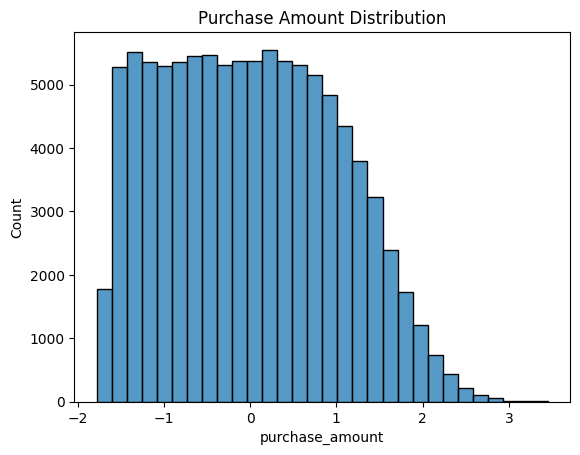

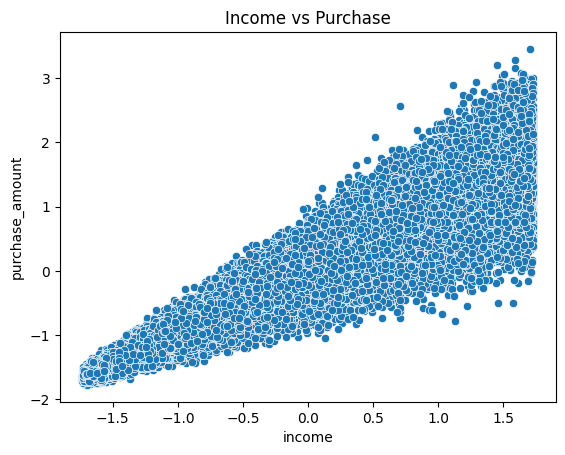

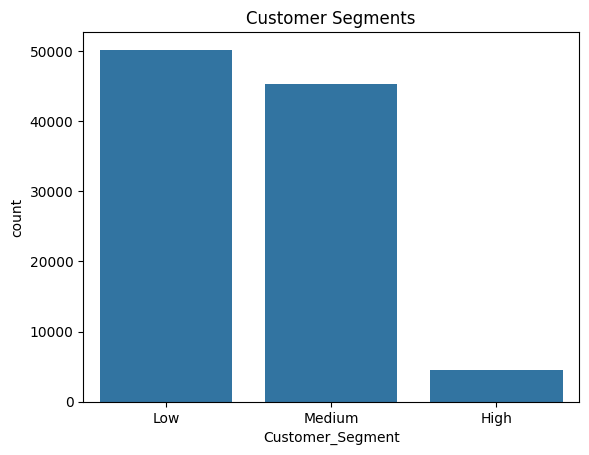

In [ ]:
# Purchase Distribution
sns.histplot(df_clean['purchase_amount'], bins=30 , kde=True)
plt.title("Purchase Amount Distribution")
plt.show()

# Income vs Purchase
sns.scatterplot(x='income', y='purchase_amount', data=df_clean)
plt.title("Income vs Purchase")
plt.show()

# Customer Segments
sns.countplot(x='Customer_Segment', data=df_clean)
plt.title("Customer Segments")
plt.show()